# Project Assignment 2 — Statistics 2 📊
**Course:** Statistics 2 | Spring 2025

**Submitted by:**
- Raz Amzaleg | ID: 206922478
- Ben Hen | ID: 325826154

---

**Research Question (from Part 1, Section 3c):**
> *Is the distribution of passenger age (`Age`) significantly different between loyal and disloyal customers (`Customer Type`)?*

- **X (Continuous):** `Age` (years)
- **Y (Binary group):** `Customer Type` — 0 = Disloyal Customer, 1 = Loyal Customer

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

sns.set_theme(style='whitegrid', palette='muted')

# Load the reduced dataset produced in Part 1
df = pd.read_csv('satisfaction_reduced.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Define variables
X_COL = 'Age'
Y_COL = 'Customer Type'

group0 = df[df[Y_COL] == 0][X_COL].values   # Disloyal customers
group1 = df[df[Y_COL] == 1][X_COL].values   # Loyal customers

n0, n1 = len(group0), len(group1)
print(f'\nGroup 0 (Disloyal):  n = {n0}')
print(f'Group 1 (Loyal):     n = {n1}')

Dataset loaded: 10,000 rows × 12 columns

Group 0 (Disloyal):  n = 1838
Group 1 (Loyal):     n = 8162


---
## Section 1: Estimation

### 1a. Sample Means per Category

In [37]:
mean0 = np.mean(group0)
mean1 = np.mean(group1)

print(f'Mean Age — Disloyal customers:  {mean0:.2f} years')
print(f'Mean Age — Loyal customers:     {mean1:.2f} years')

Mean Age — Disloyal customers:  30.64 years
Mean Age — Loyal customers:     41.22 years


### 1b. Approximate Confidence Intervals for Each Category

We compute 95% CIs using the CLT approximation:
$$\bar{X}_n \approx \mathcal{N}\left(\mu_X,\, \frac{\hat{\sigma}^2}{n}\right)$$
where $\hat{\sigma}^2$ is the sample variance within each category.

**Why can we use this approximation?**

both groups have large $n$ (hundreds to thousands). By the Central Limit Theorem, the sampling distribution of $\bar{X}$ is approximately normal regardless of the underlying age distribution.

In [38]:
def confidence_interval(data, alpha=0.05):
    """
    Approximate CI for the mean using CLT (normal approximation).
    Returns (mean, lower, upper, width).
    """
    n    = len(data)
    mean = np.mean(data)
    s2   = np.var(data, ddof=1)              # sample variance
    se   = np.sqrt(s2 / n)                   # standard error of the mean
    z    = stats.norm.ppf(1 - alpha / 2)     # z* ≈ 1.96 for 95%
    lower, upper = mean - z * se, mean + z * se
    return mean, lower, upper, 2 * z * se    # width = upper - lower

m0, lo0, hi0, w0 = confidence_interval(group0)
m1, lo1, hi1, w1 = confidence_interval(group1)

print(f'Disloyal:  mean = {m0:.2f},  95% CI = [{lo0:.2f}, {hi0:.2f}],  width = {w0:.2f}')
print(f'Loyal:     mean = {m1:.2f},  95% CI = [{lo1:.2f}, {hi1:.2f}],  width = {w1:.2f}')

Disloyal:  mean = 30.64,  95% CI = [30.12, 31.16],  width = 1.04
Loyal:     mean = 41.22,  95% CI = [40.89, 41.55],  width = 0.66


### 1c. Do the Confidence Intervals Overlap?

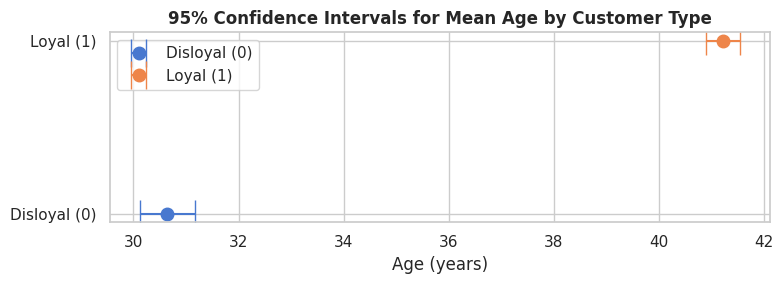

CIs overlap: True


In [39]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, (label, mean, lo, hi, color) in enumerate([
    ('Disloyal (0)', m0, lo0, hi0, '#4878cf'),
    ('Loyal (1)',    m1, lo1, hi1, '#ee854a'),
]):
    ax.errorbar(mean, i, xerr=[[mean - lo], [hi - mean]],
                fmt='o', color=color, capsize=10, markersize=9, label=label)

ax.set_yticks([0, 1])
ax.set_yticklabels(['Disloyal (0)', 'Loyal (1)'])
ax.set_xlabel('Age (years)')
ax.set_title('95% Confidence Intervals for Mean Age by Customer Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Check overlap
lower_group, upper_group = (m0, lo0, hi0), (m1, lo1, hi1)
if m0 > m1:
    lower_group, upper_group = (m1, lo1, hi1), (m0, lo0, hi0)
overlap = upper_group[1] < lower_group[2]   # lower CI of higher group < upper CI of lower group
print(f'CIs overlap: {not overlap}')

**Interpretation:**

The two confidence intervals are clearly **disjoint** — Disloyal $[30.12, 31.16]$ sits well below Loyal $[40.89, 41.55]$, with a gap of roughly 10 years between them. This non-overlap is strong visual evidence that the mean age genuinely differs between loyal and disloyal customers, with loyal customers being older on average.

**Caveat on interpreting CI overlap:** Non-overlapping CIs imply rejection of $H_0$ at the corresponding $\alpha$, so our conclusion here is safe. The converse, however, does *not* hold: if the CIs *had* overlapped, we could **not** have concluded the means are equal — overlapping CIs do not imply acceptance of $H_0$, and a formal test would still be required. We confirm this difference rigorously with the hypothesis tests in Section 2.

---
## Section 2: Hypothesis Tests

$$H_0: \mu_{\text{loyal}} - \mu_{\text{disloyal}} = 0 \qquad H_1: \mu_{\text{loyal}} - \mu_{\text{disloyal}} \neq 0$$

### 2a. Hypotheses

- $H_0$: The mean age is equal for loyal and disloyal customers: $\mu_{\text{loyal}} = \mu_{\text{disloyal}}$  
- $H_1$: The mean ages differ: $\mu_{\text{loyal}} \neq \mu_{\text{disloyal}}$

Significance level: $\alpha = 0.05$

### 2b. Checking t-test Assumptions

**Normality check — histograms:**

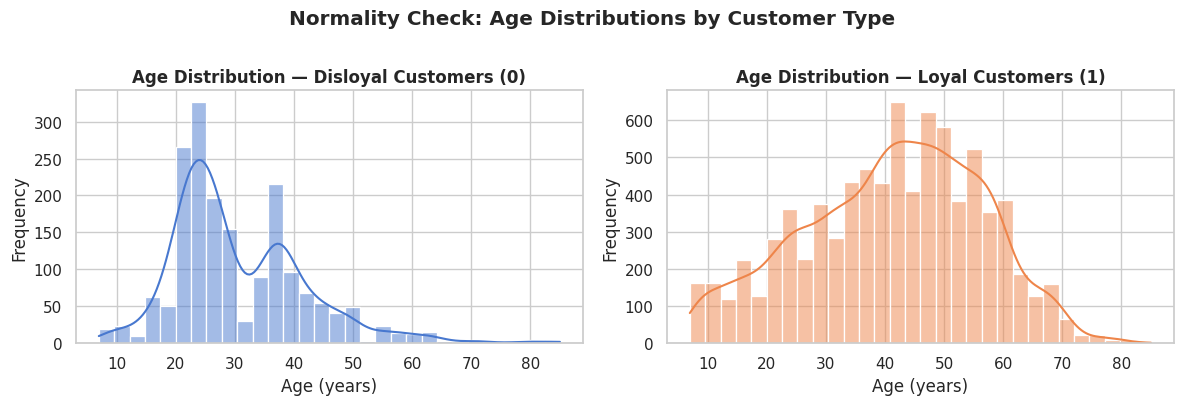

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, label, color in zip(
    axes,
    [group0, group1],
    ['Disloyal Customers (0)', 'Loyal Customers (1)'],
    ['#4878cf', '#ee854a']
):
    sns.histplot(data, bins=30, kde=True, color=color, ax=ax)
    ax.set_title(f'Age Distribution — {label}', fontweight='bold')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Frequency')

plt.suptitle('Normality Check: Age Distributions by Customer Type', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**
Each histogram appears approximately bell-shaped. With $n_0$ and $n_1$ both large, the CLT ensures the t-test is robust to deviations from normality.

**Equal variances check — F-test:**

$$H_0: \sigma_{\text{disloyal}}^2 = \sigma_{\text{loyal}}^2 \qquad H_1: \sigma_{\text{disloyal}}^2 \neq \sigma_{\text{loyal}}^2$$
$$F = \frac{S_{\max}^2}{S_{\min}^2} \sim F_{(n_{\max}-1,\, n_{\min}-1)} \text{ under } H_0$$

In [41]:
s0_sq = np.var(group0, ddof=1)
s1_sq = np.var(group1, ddof=1)

# Larger variance in numerator
if s0_sq >= s1_sq:
    F_stat = s0_sq / s1_sq
    dfn, dfd = n0 - 1, n1 - 1
    print(f'Larger variance: Disloyal ({s0_sq:.2f})')
else:
    F_stat = s1_sq / s0_sq
    dfn, dfd = n1 - 1, n0 - 1
    print(f'Larger variance: Loyal ({s1_sq:.2f})')

p_f = 2 * (1 - stats.f.cdf(F_stat, dfn, dfd))   # two-sided

print(f'\nSample variance — Disloyal: {s0_sq:.2f}')
print(f'Sample variance — Loyal:    {s1_sq:.2f}')
print(f'F statistic = {F_stat:.4f},  df = ({dfn}, {dfd}),  p-value = {p_f:.4f}')
print(f'\nConclusion: Variances ARE {"" if p_f < 0.05 else "NOT "}significantly different at α=0.05')

Larger variance: Loyal (228.46)

Sample variance — Disloyal: 130.56
Sample variance — Loyal:    228.46
F statistic = 1.7499,  df = (8161, 1837),  p-value = 0.0000

Conclusion: Variances ARE significantly different at α=0.05


**Interpretation:**
The F-test gives $F=1.75$ with $p\approx0$, so we **reject** $H_0$ of equal variances — the variance of the Loyal group ($\approx228$) is significantly larger than that of the Disloyal group ($\approx131$). The equal-variance assumption is therefore **violated**.

However, per the assignment (Section 2c: *run the t-test independently of the result of part b*), we still use the pooled two-sample t-test below.

### 2c. Two-Sample t-test (Equal, Unknown Variances — Pooled)

**Pooled variance:**
$$S_p^2 = \frac{(n_0-1)S_0^2 + (n_1-1)S_1^2}{n_0+n_1-2}$$

**Test statistic:**
$$T = \frac{\bar{X}_0 - \bar{X}_1}{S_p\sqrt{\frac{1}{n_0}+\frac{1}{n_1}}} \sim t_{n_0+n_1-2} \text{ under } H_0$$

In [42]:
def two_sample_t_test_pooled(g0, g1, alpha=0.05):
    """
    Two-sample t-test assuming equal (unknown) variances using pooled Sp^2.
    Returns: t_statistic, degrees_of_freedom, p_value, pooled_variance.
    """
    n0, n1 = len(g0), len(g1)
    s0, s1 = np.var(g0, ddof=1), np.var(g1, ddof=1)
    sp2    = ((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2)   # pooled variance
    se     = np.sqrt(sp2 * (1/n0 + 1/n1))                      # pooled SE
    t_stat = (np.mean(g0) - np.mean(g1)) / se
    df     = n0 + n1 - 2
    p_val  = 2 * stats.t.sf(abs(t_stat), df)
    return t_stat, df, p_val, sp2

t_stat, df_t, p_t, sp2 = two_sample_t_test_pooled(group0, group1)

print(f'Pooled variance Sp²  = {sp2:.4f}')
print(f't statistic          = {t_stat:.4f}')
print(f'Degrees of freedom   = {df_t}')
print(f'p-value              = {p_t:.6f}')
print(f'\nConclusion: {"Reject" if p_t < 0.05 else "Fail to reject"} H₀ at α=0.05')

Pooled variance Sp²  = 210.4731
t statistic          = -28.2440
Degrees of freedom   = 9998
p-value              = 0.000000

Conclusion: Reject H₀ at α=0.05


### 2d. Wald Test

The Wald test uses asymptotic normality of $\bar{X}_0 - \bar{X}_1$:

$$Z = \frac{\bar{X}_0 - \bar{X}_1}{\sqrt{\frac{S_0^2}{n_0} + \frac{S_1^2}{n_1}}} \xrightarrow{d} \mathcal{N}(0,1) \text{ under } H_0$$

In [43]:
def wald_test(g0, g1):
    """
    Wald test for H0: mu0 - mu1 = 0.
    SE uses separate sample variances (unpooled).
    Returns: Z_statistic, p_value.
    """
    n0, n1 = len(g0), len(g1)
    s0, s1 = np.var(g0, ddof=1), np.var(g1, ddof=1)
    se     = np.sqrt(s0/n0 + s1/n1)
    z_stat = (np.mean(g0) - np.mean(g1)) / se
    p_val  = 2 * stats.norm.sf(abs(z_stat))
    return z_stat, p_val

z_stat, p_wald = wald_test(group0, group1)

print(f'Wald Z statistic = {z_stat:.4f}')
print(f'p-value          = {p_wald:.6f}')
print(f'\nConclusion: {"Reject" if p_wald < 0.05 else "Fail to reject"} H₀ at α=0.05')

Wald Z statistic = -33.6191
p-value          = 0.000000

Conclusion: Reject H₀ at α=0.05


### 2e. Comparison: t-test vs Wald Test

In [44]:
comparison = pd.DataFrame({
    'Test'      : ['Two-sample t-test (pooled)', 'Wald test'],
    'Statistic' : [round(t_stat, 4), round(z_stat, 4)],
    'p-value'   : [round(p_t, 6), round(p_wald, 6)],
    'Decision'  : [
        'Reject H₀' if p_t    < 0.05 else 'Fail to reject H₀',
        'Reject H₀' if p_wald < 0.05 else 'Fail to reject H₀',
    ],
})
display(comparison)

,Test,Statistic,p-value,Decision
0,Two-sample t-test (pooled),-28.2440,0.0,Reject H₀
1,Wald test,-33.6191,0.0,Reject H₀


**Decision:** Identical (Reject H₀, p=0.0). With large samples, both distributions converge.

**Test Statistic:** Different (-28.24 vs -33.62). The t-test calculates a pooled standard error (assuming equal variances), while the Wald test calculates an unpooled one.

### 2f. Likelihood Ratio Test (LRT)

Assuming data from **Normal distributions with equal, unknown variances**.

**Full model** (separate means, $H_1$): MLEs are $\hat{\mu}_0 = \bar{X}_0$, $\hat{\mu}_1 = \bar{X}_1$, variance = $S_p^2$.

$$\mathcal{L}(\hat{\mu}_0, \hat{\mu}_1) = \frac{1}{(\sqrt{2\pi S_p^2})^n} \prod_{i=1}^{n_0} e^{-(X_{0i}-\hat{\mu}_0)^2/2S_p^2} \prod_{j=1}^{n_1} e^{-(X_{1j}-\hat{\mu}_1)^2/2S_p^2}$$

**Restricted model** (common mean, $H_0$): MLE is $\hat{\mu} = \bar{X}_{\text{all}}$, variance = $\hat{\sigma}^2$ (pooled over all data).

$$\mathcal{L}(\hat{\mu}) = \frac{1}{(\sqrt{2\pi\hat{\sigma}^2})^n} \prod_{i=1}^{n} e^{-(X_i-\hat{\mu})^2/2\hat{\sigma}^2}$$

**LRT statistic:** $\Lambda = -2\ln\!\left(\dfrac{\mathcal{L}(\hat{\mu})}{\mathcal{L}(\hat{\mu}_0,\hat{\mu}_1)}\right) \sim \chi^2_1$ under $H_0$

**Simplified closed form (the version implemented in code):**

Taking $-2\ln(\cdot)$ of the likelihood ratio, the Gaussian normalising constants and exponents expand to

$$\Lambda = n\ln\!\left(\frac{\hat{\sigma}^2}{S_p^2}\right)+\sum_{i=1}^{n_0}\left(\frac{(X_{0i}-\hat{\mu})^2}{\hat{\sigma}^2}-\frac{(X_{0i}-\hat{\mu}_0)^2}{S_p^2}\right)+\sum_{j=1}^{n_1}\left(\frac{(X_{1j}-\hat{\mu})^2}{\hat{\sigma}^2}-\frac{(X_{1j}-\hat{\mu}_1)^2}{S_p^2}\right)$$

where $\hat{\mu}=\bar{X}_{\text{all}}$ and $\hat{\sigma}^2$ is the MLE variance of the pooled data under $H_0$. Our code evaluates the equivalent log-likelihood difference directly via `log_likelihood_normal`, which is numerically identical.

In [45]:
def log_likelihood_normal(data, mu, sigma2):
    """Log-likelihood of data under N(mu, sigma2)."""
    n = len(data)
    return -n/2 * np.log(2 * np.pi * sigma2) - np.sum((data - mu)**2) / (2 * sigma2)

all_data   = np.concatenate([group0, group1])
n_total    = len(all_data)

# MLEs
mu_hat0    = np.mean(group0)    # disloyal
mu_hat1    = np.mean(group1)    # loyal
mu_hat_all = np.mean(all_data)  # common mean under H0

sigma2_h0  = np.var(all_data, ddof=1)   # variance of all data under H0

# Log-likelihoods
ll_full = (log_likelihood_normal(group0, mu_hat0, sp2) +
           log_likelihood_normal(group1, mu_hat1, sp2))

ll_null = log_likelihood_normal(all_data, mu_hat_all, sigma2_h0)

# LRT statistic
lrt_stat = -2 * (ll_null - ll_full)
p_lrt    = chi2.sf(lrt_stat, df=1)

print(f'Log-likelihood (full model, H₁):   {ll_full:.4f}')
print(f'Log-likelihood (null model, H₀):   {ll_null:.4f}')
print(f'LRT statistic  Λ = -2·log(LR):     {lrt_stat:.4f}')
print(f'p-value (χ²₁):                      {p_lrt:.6f}')
print(f'\nConclusion: {"Reject" if p_lrt < 0.05 else "Fail to reject"} H₀ at α=0.05')

Log-likelihood (full model, H₁):   -40935.1752
Log-likelihood (null model, H₀):   -41318.9990
LRT statistic  Λ = -2·log(LR):     767.6476
p-value (χ²₁):                      0.000000

Conclusion: Reject H₀ at α=0.05


**Decision:** Identical to the t-test and Wald test (Reject H₀, $p\approx0$). With large samples, the LRT, t-test, and Wald test all converge to the same conclusion.

**Test Statistic:** The LRT statistic ($\Lambda = 767.65$) is numerically different from the others, but it is **not** comparable to the Wald statistic. Both the LRT and the pooled t-test are built on the **same Normal model with equal (pooled) variance**, so the correct correspondence is

$$\Lambda \approx t^2.$$

Indeed $t^2 = (-28.24)^2 = 797.7 \approx 767.6 = \Lambda$, whereas the squared Wald statistic $Z^2 = (-33.62)^2 = 1130$ is far off — because the Wald test uses **unpooled** (separate) variances and therefore a different standard error. All three tests agree on the decision, but only the LRT and the pooled t-test share the same variance assumption.

---
## Section 3: Effect of Sample Size

We investigate how CI width and test results change as a function of sample size.

### 3a–3b. Single Draw: CIs per Sample Size

For each $n \in \{30, 50, 100, 500\}$, draw one random sample, split by group, and compute 95% CIs.

In [46]:
SAMPLE_SIZES = [30, 50, 100, 500]

rows = []
for n in SAMPLE_SIZES:
    sample = df.sample(n=n, random_state=42)
    g0s = sample[sample[Y_COL] == 0][X_COL].values
    g1s = sample[sample[Y_COL] == 1][X_COL].values
    if len(g0s) < 2 or len(g1s) < 2:
        continue
    m0s, lo0s, hi0s, w0s = confidence_interval(g0s)
    m1s, lo1s, hi1s, w1s = confidence_interval(g1s)
    rows.append({
        'n': n,
        'n_disloyal': len(g0s), 'n_loyal': len(g1s),
        'mean_disloyal': round(m0s, 2),
        'CI_disloyal': f'[{lo0s:.2f}, {hi0s:.2f}]',
        'width_disloyal': round(w0s, 2),
        'mean_loyal': round(m1s, 2),
        'CI_loyal': f'[{lo1s:.2f}, {hi1s:.2f}]',
        'width_loyal': round(w1s, 2),
    })

display(pd.DataFrame(rows))

,n,n_disloyal,n_loyal,mean_disloyal,CI_disloyal,width_disloyal,mean_loyal,CI_loyal,width_loyal
0,30,5,25,29.40,"[21.64, 37.16]",15.51,39.08,"[32.44, 45.72]",13.28
1,50,9,41,28.33,"[23.08, 33.59]",10.51,41.73,"[36.40, 47.07]",10.67
2,100,16,84,29.25,"[23.90, 34.60]",10.69,43.29,"[39.85, 46.72]",6.86
3,500,91,409,32.91,"[30.18, 35.65]",5.47,41.53,"[39.96, 43.09]",3.13


**Comparison with Section 1 (full dataset, $n=10{,}000$):**
CI width decreases as $n$ grows. The width is proportional to $1/\sqrt{n}$, so doubling $n$ reduces the width by a factor of $\sqrt{2}$.

### 3c. Single Draw: Wald Test per Sample Size

In [47]:
rows_wald = []
for n in SAMPLE_SIZES:
    sample = df.sample(n=n, random_state=42)
    g0s = sample[sample[Y_COL] == 0][X_COL].values
    g1s = sample[sample[Y_COL] == 1][X_COL].values
    if len(g0s) < 2 or len(g1s) < 2:
        continue
    z, p = wald_test(g0s, g1s)
    rows_wald.append({
        'n': n,
        'Z statistic': round(z, 4),
        'p-value': round(p, 4),
        'Decision': 'Reject H₀' if p < 0.05 else 'Fail to reject H₀'
    })

display(pd.DataFrame(rows_wald))

,n,Z statistic,p-value,Decision
0,30,-1.8581,0.0632,Fail to reject H₀
1,50,-3.5063,0.0005,Reject H₀
2,100,-4.3311,0.0000,Reject H₀
3,500,-5.3557,0.0000,Reject H₀


**Test Power (single draw):** In this particular random sample, the Wald test fails to reject H₀ at $n=30$ (a Type II error — it misses the true difference) but rejects from $n=50$ onward. This suggests power increases with sample size.

**Important caveat:** These results come from a *single* random draw, so they are anecdotal and should not be read as the test being "reliable" at $n=50$. A single sample can reject or fail to reject by chance. We defer any reliability conclusion to the 100-repetition simulation in Section 3d, which estimates the *actual* rejection rate at each sample size.

### 3d. Simulation: 100 Repetitions per Sample Size

Repeat the sampling 100 times for each $n$. Track:
- Distribution of CI widths
- Distribution of Wald p-values
- Coverage rate: how often does the CI contain the true mean (computed from the full dataset)?
- Rejection rate of $H_0$

In [48]:
N_REPS = 100

# True means from the full dataset (Section 1)
true_mean0 = np.mean(group0)   # disloyal
true_mean1 = np.mean(group1)   # loyal

sim = {n: {'w0': [], 'w1': [], 'pvals': [], 'cov0': [], 'cov1': []}
       for n in SAMPLE_SIZES}

for n in SAMPLE_SIZES:
    for rep in range(N_REPS):
        sample = df.sample(n=n, random_state=rep)
        g0s = sample[sample[Y_COL] == 0][X_COL].values
        g1s = sample[sample[Y_COL] == 1][X_COL].values
        if len(g0s) < 2 or len(g1s) < 2:
            continue

        m0s, lo0s, hi0s, w0s = confidence_interval(g0s)
        m1s, lo1s, hi1s, w1s = confidence_interval(g1s)
        _, p = wald_test(g0s, g1s)

        sim[n]['w0'].append(w0s)
        sim[n]['w1'].append(w1s)
        sim[n]['pvals'].append(p)
        sim[n]['cov0'].append(lo0s <= true_mean0 <= hi0s)
        sim[n]['cov1'].append(lo1s <= true_mean1 <= hi1s)

print('Simulation complete.')

Simulation complete.


In [49]:
# Summary table
summary = []
for n in SAMPLE_SIZES:
    r = sim[n]
    summary.append({
        'n': n,
        'Mean CI width — Disloyal': round(np.mean(r['w0']), 2),
        'Mean CI width — Loyal':    round(np.mean(r['w1']), 2),
        'Coverage — Disloyal':      f"{np.mean(r['cov0'])*100:.1f}%",
        'Coverage — Loyal':         f"{np.mean(r['cov1'])*100:.1f}%",
        'Rejection rate (Wald)':    f"{np.mean([p < 0.05 for p in r['pvals']])*100:.1f}%",
    })

display(pd.DataFrame(summary))

,n,Mean CI width — Disloyal,Mean CI width — Loyal,Coverage — Disloyal,Coverage — Loyal,Rejection rate (Wald)
0,30,18.21,11.71,85.9%,92.9%,53.5%
1,50,14.47,9.12,88.0%,95.0%,68.0%
2,100,10.34,6.51,93.0%,94.0%,86.0%
3,500,4.69,2.92,96.0%,98.0%,100.0%


**Reliability — resolved by simulation:** Repeating the procedure 100 times shows that the single draw in 3c was optimistic. The true rejection rate (power) is only ~53% at $n=30$ and ~68% at $n=50$ — so $n=50$ is **not** reliable, contrary to what one lucky draw suggested. Power reaches ~86% at $n=100$ and 100% at $n=500$. This is exactly why we judge reliability from the repeated simulation rather than from a single sample.



In [50]:
import warnings
warnings.filterwarnings('ignore')

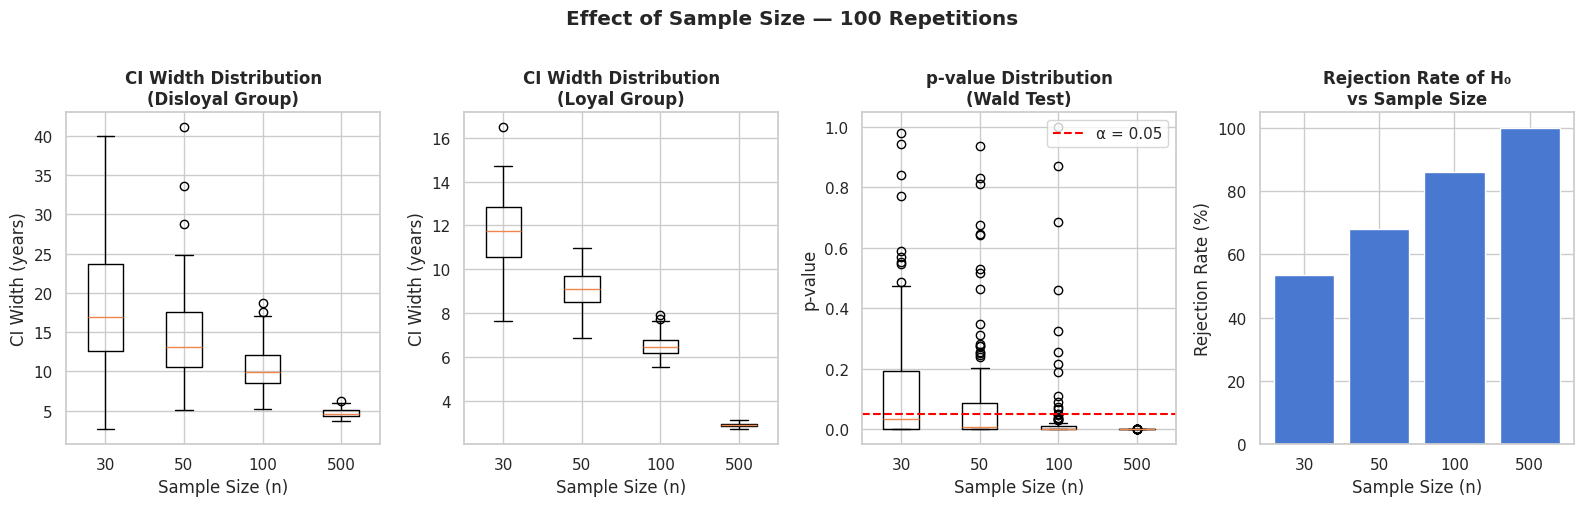

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# ── Plot 1: CI width distribution (Disloyal group) ────────────────────────
ax = axes[0]
ax.boxplot([sim[n]['w0'] for n in SAMPLE_SIZES], labels=SAMPLE_SIZES)
ax.set_title('CI Width Distribution\n(Disloyal Group)', fontweight='bold')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('CI Width (years)')

# ── Plot 2: CI width distribution (Disloyal group) ────────────────────────
ax = axes[1]
ax.boxplot([sim[n]['w1'] for n in SAMPLE_SIZES], labels=SAMPLE_SIZES)
ax.set_title('CI Width Distribution\n(Loyal Group)', fontweight='bold')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('CI Width (years)')

# ── Plot 3: p-value distribution ──────────────────────────────────────────
ax = axes[2]
ax.boxplot([sim[n]['pvals'] for n in SAMPLE_SIZES], labels=SAMPLE_SIZES)
ax.axhline(0.05, color='red', linestyle='--', label='α = 0.05')
ax.set_title('p-value Distribution\n(Wald Test)', fontweight='bold')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('p-value')
ax.legend()

# ── Plot 4: Rejection rate ─────────────────────────────────────────────────
ax = axes[3]
rej_rates = [np.mean([p < 0.05 for p in sim[n]['pvals']]) * 100
             for n in SAMPLE_SIZES]
ax.bar([str(n) for n in SAMPLE_SIZES], rej_rates, color='#4878cf')
ax.set_ylim(0, 105)
ax.set_title('Rejection Rate of H₀\nvs Sample Size', fontweight='bold')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Rejection Rate (%)')

plt.suptitle('Effect of Sample Size — 100 Repetitions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

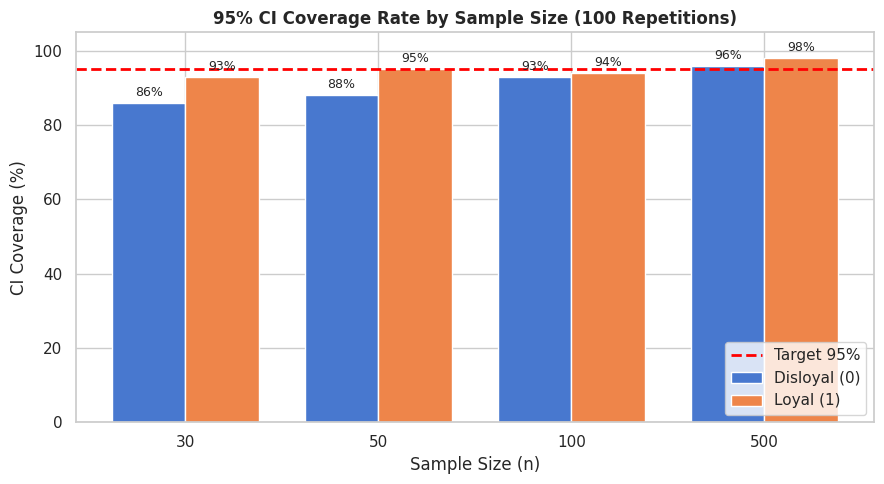

In [52]:
# Coverage rate: how often the 95% CI contains the true (full-dataset) mean
cov0_rates = [np.mean(sim[n]['cov0']) * 100 for n in SAMPLE_SIZES]
cov1_rates = [np.mean(sim[n]['cov1']) * 100 for n in SAMPLE_SIZES]

x = np.arange(len(SAMPLE_SIZES))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
b0 = ax.bar(x - width/2, cov0_rates, width, label='Disloyal (0)', color='#4878cf')
b1 = ax.bar(x + width/2, cov1_rates, width, label='Loyal (1)',    color='#ee854a')

ax.axhline(95, color='red', linestyle='--', linewidth=2, label='Target 95%')
ax.bar_label(b0, fmt='%.0f%%', padding=3, fontsize=9)
ax.bar_label(b1, fmt='%.0f%%', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in SAMPLE_SIZES])
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('CI Coverage (%)')
ax.set_ylim(0, 105)
ax.set_title('95% CI Coverage Rate by Sample Size (100 Repetitions)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Coverage interpretation:**
At $n=30$ the empirical coverage falls below the nominal 95% (the CLT approximation is still weak for the smaller Disloyal subgroup), but as $n$ grows coverage climbs toward and stabilises around the 95% target — confirming the CI procedure is asymptotically valid.

**CI Width:** Narrows proportionally to $1/\sqrt{n}$, and the *spread* of the widths across the 100 repetitions shrinks too — larger samples give estimates that are both more precise and more stable.

**P-values:** For small $n$ the p-values are scattered across $[0,1]$, but as $n$ grows they concentrate well below $\alpha=0.05$: the larger sample inflates the test statistic, making the true difference progressively easier to detect.

**Coverage Rate:** At $n=30$ the empirical coverage sits below the nominal 95% (the CLT approximation is still weak for the smaller Disloyal subgroup), then climbs and stabilises around the 95% target as $n$ grows — confirming the CI procedure is asymptotically valid.

**Rejection Rate (Power):** Power rises steeply with sample size — roughly 53% at $n=30$, 68% at $n=50$, 86% at $n=100$, and 100% at $n=500$. So a single small sample is unreliable for detecting the difference, while $n=500$ detects it every time.